In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shutil
import os
import polars as pl
from tqdm.notebook import tqdm

In [2]:
##### ‼️⚠️ THIS CELL MIGHT TAKE AROUND 15 MIN TO LOAD THE ENTIRE METADATA IF IT IS YOUR FIRST TIME RUNNING IT ‼️⚠️
##### ‼️⚠️ IT DOWNLOADS THE DATASET IN YOUR CACHE AND MAY TAKE SOME SPACE ‼️⚠️
DOWNLOAD = True
if DOWNLOAD:
    path = kagglehub.dataset_download("lokeshparab/gutenberg-books-and-metadata-2025")
else:
    your_path = '/Users/eglantinevialaneix'
    path =  your_path + '/.cache/kagglehub/datasets/lokeshparab/gutenberg-books-and-metadata-2025/versions/4/'

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gutenberg-books-and-metadata-2025' dataset.
Path to dataset files: /kaggle/input/gutenberg-books-and-metadata-2025


In [3]:
total, used, free = shutil.disk_usage(os.path.expanduser("~/.cache/kagglehub"))
print(f"Total cache: {total / 1024**2:.2f} MB")
print(f"Cache used: {used / 1024**2:.2f} MB = {100 * used / total:.2f} %")
print(f"Free left: {free / 1024**2:.2f} MB = {100 * free / total:.2f} %")

Total cache: 110300.25 MB
Cache used: 61441.10 MB = 55.70 %
Free left: 48843.15 MB = 44.28 %


In [4]:
import os

total = 0
for dirpath, dirnames, filenames in os.walk(path):
    for f in filenames:
        fp = os.path.join(dirpath, f)
        total += os.path.getsize(fp)

print(f"Folder size: {total / 1024**3:.2f} GB")

Folder size: 28.86 GB


In [5]:
file_count = sum(len(files) for _, _, files in os.walk(path + "/books"))
print(f"Total number of books: {file_count}")

Total number of books: 75370


In [6]:
print(f"The csv file takes {os.path.getsize(path + "/gutenberg_metadata.csv") / 1024**2:.2f} MB of memory.")

The csv file takes 83.68 MB of memory.


In [7]:
df_raw = pd.read_csv(path + "/gutenberg_metadata.csv")
df_raw

,Etext Number,Type,Issued,Title,Language,LoCC,Bookshelves,Authors,rights,Subjects,...,EPUB3 (E-readers incl. Send-to-Kindle),EPUB (older E-readers),"EPUB (no images, older E-readers)",Kindle,Kindle (E-readers incl. Send-to-Kindle),"Kindle (no images, older E-readers)",Plain Text UTF-8,Download HTML(zip),Resource Description Framework (RDF),Other Links
0,1,Text,1971-12-01,The Declaration of Independence of the United ...,en,E201; JK,Politics; American Revolutionary War; United S...,"Jefferson, Thomas",Public domain in the USA.,E201 ; JK ; United States -- History -- Revolu...,...,https://www.gutenberg.org/ebooks/1.epub3.images,https://www.gutenberg.org/ebooks/1.epub.images,https://www.gutenberg.org/ebooks/1.epub.noimages,https://www.gutenberg.org/ebooks/1.kf8.images,https://www.gutenberg.org/ebooks/1.kindle.images,https://www.gutenberg.org/ebooks/1.kindle.noim...,https://www.gutenberg.org/ebooks/1.txt.utf-8,https://www.gutenberg.org/files/1/1-h.zip,https://www.gutenberg.org/ebooks/1.rdf,https://www.gutenberg.org/files/1/1-h/1-h.htm ...
1,2,Text,1972-12-01,The United States Bill of Rights\r\nThe Ten Or...,en,JK; KF,Politics; American Revolutionary War; United S...,United States,Public domain in the USA.,Civil rights -- United States -- Sources ; JK ...,...,https://www.gutenberg.org/ebooks/2.epub3.images,https://www.gutenberg.org/ebooks/2.epub.images,https://www.gutenberg.org/ebooks/2.epub.noimages,https://www.gutenberg.org/ebooks/2.kf8.images,https://www.gutenberg.org/ebooks/2.kindle.images,https://www.gutenberg.org/ebooks/2.kindle.noim...,https://www.gutenberg.org/ebooks/2.txt.utf-8,https://www.gutenberg.org/files/2/2-h.zip,https://www.gutenberg.org/ebooks/2.rdf,https://www.gutenberg.org/files/2/2-h/2-h.htm ...
2,3,Text,1973-11-01,John F. Kennedy's Inaugural Address,en,E838,Browsing: History - American; Browsing: Politics,"Kennedy, John F. (John Fitzgerald)",Public domain in the USA.,E838 ; United States -- Foreign relations -- 1...,...,https://www.gutenberg.org/ebooks/3.epub3.images,https://www.gutenberg.org/ebooks/3.epub.images,https://www.gutenberg.org/ebooks/3.epub.noimages,https://www.gutenberg.org/ebooks/3.kf8.images,https://www.gutenberg.org/ebooks/3.kindle.images,https://www.gutenberg.org/ebooks/3.kindle.noim...,https://www.gutenberg.org/ebooks/3.txt.utf-8,https://www.gutenberg.org/cache/epub/3/pg3-h.zip,https://www.gutenberg.org/ebooks/3.rdf,https://www.gutenberg.org/cache/epub/3/pg3.cov...
3,4,Text,1973-11-01,Lincoln's Gettysburg Address\r\nGiven November...,en,E456,US Civil War; Browsing: History - American; Br...,"Lincoln, Abraham",Public domain in the USA.,E456 ; Soldiers' National Cemetery (Gettysburg...,...,https://www.gutenberg.org/ebooks/4.epub3.images,https://www.gutenberg.org/ebooks/4.epub.images,https://www.gutenberg.org/ebooks/4.epub.noimages,https://www.gutenberg.org/ebooks/4.kf8.images,https://www.gutenberg.org/ebooks/4.kindle.images,https://www.gutenberg.org/ebooks/4.kindle.noim...,https://www.gutenberg.org/ebooks/4.txt.utf-8,https://www.gutenberg.org/cache/epub/4/pg4-h.zip,https://www.gutenberg.org/ebooks/4.rdf,https://www.gutenberg.org/files/4/4.zip ; http...
4,5,Text,1975-12-01,The United States Constitution,en,JK; KF,United States; Politics; American Revolutionar...,United States,Public domain in the USA.,JK ; United States. Constitution ; United Stat...,...,https://www.gutenberg.org/ebooks/5.epub3.images,https://www.gutenberg.org/ebooks/5.epub.images,https://www.gutenberg.org/ebooks/5.epub.noimages,https://www.gutenberg.org/ebooks/5.kf8.images,https://www.gutenberg.org/ebooks/5.kindle.images,https://www.gutenberg.org/ebooks/5.kindle.noim...,https://www.gutenberg.org/ebooks/5.txt.utf-8,https://www.gutenberg.org/files/5/5-h.zip,https://www.gutenberg.org/ebooks/5.rdf,https://www.gutenberg.org/files/5/5.txt ; http...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75389,75565,Text,2025-03-08,The man with a grouch,en,NaN,NaN,"Stacpoole, H. De Vere (Henry De Vere), 

shape: (75394, 21)
columns: ['Etext Number', 'Type', 'Issued', 'Title', 'Language', 'LoCC', 'Bookshelves', 'Authors', 'rights', 'Subjects', 'Read online (web)', 'EPUB3 (E-readers incl. Send-to-Kindle)', 'EPUB (older E-readers)', 'EPUB (no images, older E-readers)', 'Kindle', 'Kindle (E-readers incl. Send-to-Kindle)', 'Kindle (no images, older E-readers)', 'Plain Text UTF-8', 'Download HTML(zip)', 'Resource Description Framework (RDF)', 'Other Links']

--- dtypes ---
Etext Number                                int64
Type                                       object
Issued                                     object
Title                                      object
Language                                   object
LoCC                                       object
Bookshelves                                object
Authors                                    object
rights                                     object
Subjects                                   object
Read online (web)            

,Etext Number,Type,Issued,Title,Language,LoCC,Bookshelves,Authors,rights,Subjects,...,EPUB3 (E-readers incl. Send-to-Kindle),EPUB (older E-readers),"EPUB (no images, older E-readers)",Kindle,Kindle (E-readers incl. Send-to-Kindle),"Kindle (no images, older E-readers)",Plain Text UTF-8,Download HTML(zip),Resource Description Framework (RDF),Other Links
0,1,Text,1971-12-01,The Declaration of Independence of the United ...,en,E201; JK,Politics; American Revolutionary War; United S...,"Jefferson, Thomas",Public domain in the USA.,E201 ; JK ; United States -- History -- Revolu...,...,https://www.gutenberg.org/ebooks/1.epub3.images,https://www.gutenberg.org/ebooks/1.epub.images,https://www.gutenberg.org/ebooks/1.epub.noimages,https://www.gutenberg.org/ebooks/1.kf8.images,https://www.gutenberg.org/ebooks/1.kindle.images,https://www.gutenberg.org/ebooks/1.kindle.noim...,https://www.gutenberg.org/ebooks/1.txt.utf-8,https://www.gutenberg.org/files/1/1-h.zip,https://www.gutenberg.org/ebooks/1.rdf,https://www.gutenberg.org/files/1/1-h/1-h.htm ...
1,2,Text,1972-12-01,The United States Bill of Rights\r\nThe Ten Or...,en,JK; KF,Politics; American Revolutionary War; United S...,United States,Public domain in the USA.,Civil rights -- United States -- Sources ; JK ...,...,https://www.gutenberg.org/ebooks/2.epub3.images,https://www.gutenberg.org/ebooks/2.epub.images,https://www.gutenberg.org/ebooks/2.epub.noimages,https://www.gutenberg.org/ebooks/2.kf8.images,https://www.gutenberg.org/ebooks/2.kindle.images,https://www.gutenberg.org/ebooks/2.kindle.noim...,https://www.gutenberg.org/ebooks/2.txt.utf-8,https://www.gutenberg.org/files/2/2-h.zip,https://www.gutenberg.org/ebooks/2.rdf,https://www.gutenberg.org/files/2/2-h/2-h.htm ...
2,3,Text,1973-11-01,John F. Kennedy's Inaugural Address,en,E838,Browsing: History - American; Browsing: Politics,"Kennedy, John F. (John Fitzgerald)",Public domain in the USA.,E838 ; United States -- Foreign relations -- 1...,...,https://www.gutenberg.org/ebooks/3.epub3.images,https://www.gutenberg.org/ebooks/3.epub.images,https://www.gutenberg.org/ebooks/3.epub.noimages,https://www.gutenberg.org/ebooks/3.kf8.images,https://www.gutenberg.org/ebooks/3.kindle.images,https://www.gutenberg.org/ebooks/3.kindle.noim...,https://www.gutenberg.org/ebooks/3.txt.utf-8,https://www.gutenberg.org/cache/epub/3/pg3-h.zip,https://www.gutenberg.org/ebooks/3.rdf,https://www.gutenberg.org/cache/epub/3/pg3.cov...
3,4,Text,1973-11-01,Lincoln's Gettysburg Address\r\nGiven November...,en,E456,US Civil War; Browsing: History - American; Br...,"Lincoln, Abraham",Public domain in the USA.,E456 ; Soldiers' National Cemetery (Gettysburg...,...,https://www.gutenberg.org/ebooks/4.epub3.images,https://www.gutenberg.org/ebooks/4.epub.images,https://www.gutenberg.org/ebooks/4.epub.noimages,https://www.gutenberg.org/ebooks/4.kf8.images,https://www.gutenberg.org/ebooks/4.kindle.images,https://www.gutenberg.org/ebooks/4.kindle.noim...,https://www.gutenberg.org/ebooks/4.txt.utf-8,https://www.gutenberg.org/cache/epub/4/pg4-h.zip,https://www.gutenberg.org/ebooks/4.rdf,https://www.gutenberg.org/files/4/4.zip ; http...
4,5,Text,1975-12-01,The United States Constitution,en,JK; KF,United States; Politics; American Revolutionar...,United States,Public domain in the USA.,JK ; United States. Constitution ; United Stat...,...,https://www.gutenberg.org/ebooks/5.epub3.images,https://www.gutenberg.org/ebooks/5.epub.images,https://www.gutenberg.org/ebooks/5.epub.noimages,https://www.gutenberg.org/ebooks/5.kf8.images,https://www.gutenberg.org/ebooks/5.kindle.images,https://www.gutenberg.org/ebooks/5.kindle.noim...,https://www.gutenberg.org/ebooks/5.txt.utf-8,https://www.gutenberg.org/files/5/5-h.zip,https://www.gutenberg.org/ebooks/5.rdf,https://www.gutenberg.org/files/5/5.txt ; http...
5,6,Text,1976-12-01,Give Me Liberty or Give Me Death,en,E201,American Revolutionary War; Browsing: History ...,"Henry, Patrick",Public domain in the USA.,E201 ; United States -- Politics an

,Etext Number,Type,Issued,Title,Language,LoCC,Bookshelves,Authors,rights,Subjects,...,EPUB3 (E-readers incl. Send-to-Kindle),EPUB (older E-readers),"EPUB (no images, older E-readers)",Kindle,Kindle (E-readers incl. Send-to-Kindle),"Kindle (no images, older E-readers)",Plain Text UTF-8,Download HTML(zip),Resource Description Framework (RDF),Other Links
75389,75565,Text,2025-03-08,The man with a grouch,en,NaN,NaN,"Stacpoole, H. De Vere (Henry De Vere), 1863-1951",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75390,75566,Text,2025-03-08,Visibility—Zero,en,NaN,NaN,"Stearns, Myron M. (Myron Morris), 1884-1963",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75391,75567,Text,2025-03-09,Highland annals,en,NaN,NaN,"Dargan, Olive Tilford, 1869-1968",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75392,75568,Text,2025-03-09,Franz Schuberts Lebenslied,de,NaN,NaN,"Lux, Joseph Aug. (Joseph August), 1871-1947",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75393,75569,Text,2025-03-09,Als ich noch der Waldbauernbub war. 2. Band.,de,NaN,NaN,"Rosegger, Peter, 1843-1918",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75394 entries, 0 to 75393
Data columns (total 21 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   Etext Number                             75394 non-null  int64 
 1   Type                                     75394 non-null  object
 2   Issued                                   75394 non-null  object
 3   Title                                    75394 non-null  object
 4   Language                                 75394 non-null  object
 5   LoCC                                     75126 non-null  object
 6   Bookshelves                              75046 non-null  object
 7   Authors                                  72614 non-null  object
 8   rights                                   75377 non-null  object
 9   Subjects                                 75317 non-null  object
 10  Read online (web)                        73953 non-null  o

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Etext Number,75394.0,NaN,NaN,NaN,37773.992387,21786.201116,1.0,18919.25,37770.5,56618.75,75569.0
Type,75394,7,Text,74143,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Issued,75394,7680,2004-02-01,672,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Title,75394,73651,Poems,69,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Language,75394,119,en,60177,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LoCC,75126,1363,PS,11445,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bookshelves,75046,8403,Browsing: Literature; Browsing: Fiction,5313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Authors,72614,24998,Various,3945,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rights,75377,2,Public domain in the USA.,74506,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Subjects,75317,45369,AP ; English wit and humor -- Periodicals,551,NaN,NaN,NaN,NaN,NaN,NaN,NaN


...

,count
Title,
Poems,69
State of the Union Addresses,39
The Philistine,14
A Child's Garden of Verses,9
Othello,7
Macbeth,7
Gedichte,7
Runoelmia,6
Runoja,6



Numeric columns: ['Etext Number']


,count,mean,std,min,25%,50%,75%,max
Etext Number,75394.0,37773.992387,21786.201116,1.0,18919.25,37770.5,56618.75,75569.0


,0
Authors,0.036873
Bookshelves,0.004616
LoCC,0.003555
Language,0.000000
Type,0.000000
Issued,0.000000


EDA summary keys: ['shape', 'missing', 'dtypes', 'top_languages']


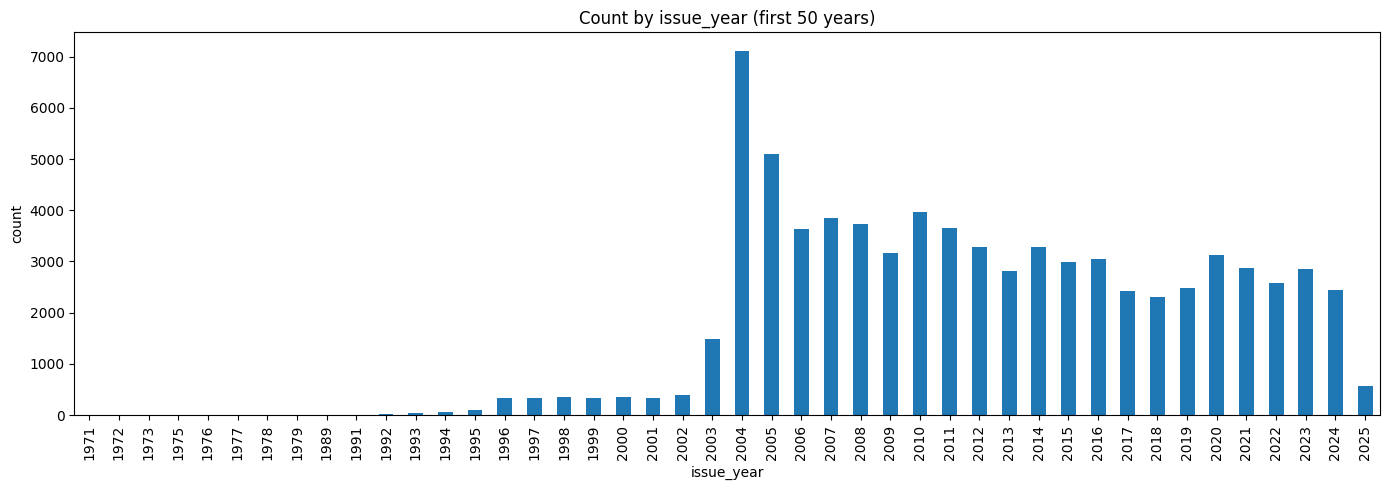

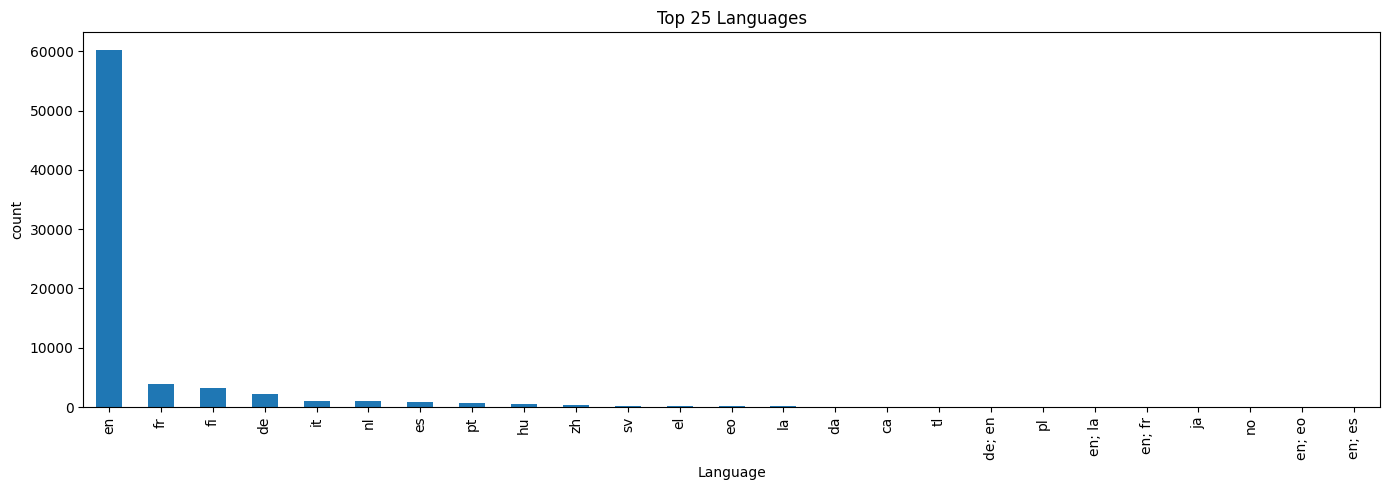

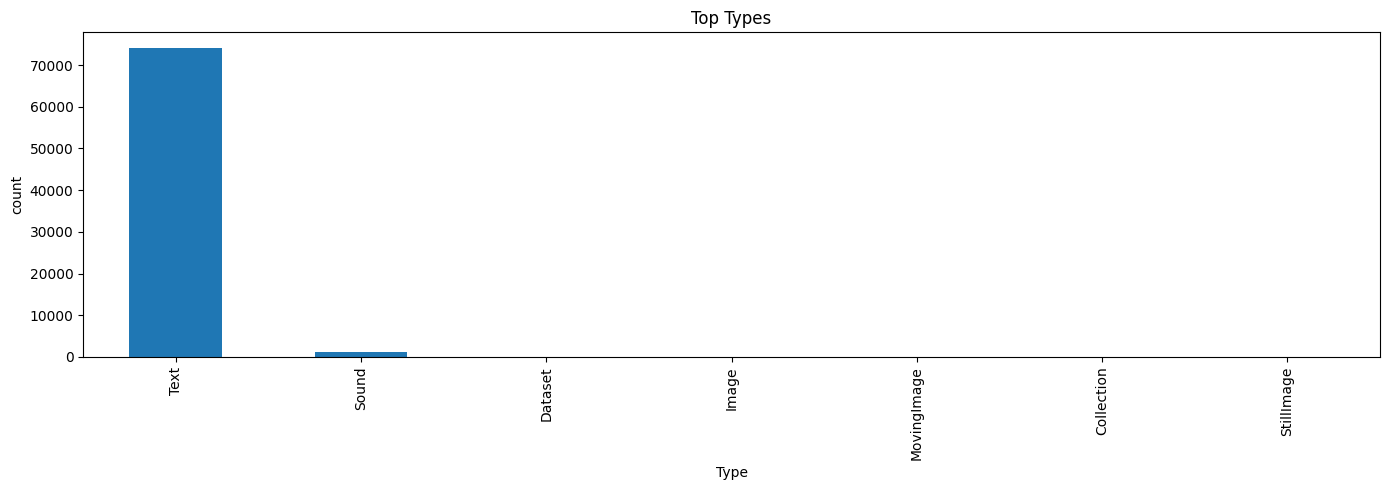

In [8]:
# Quick EDA summary for df_raw

# 1) Basic structure
print("shape:", df_raw.shape)
print("columns:", list(df_raw.columns))
print("\n--- dtypes ---")
print(df_raw.dtypes)

# 2) Peek at data
display(df_raw.head(10))
display(df_raw.tail(5))

# 3) Info + basic statistics
df_raw.info(memory_usage="deep")
display(df_raw.describe(include="all").T)

# 4) Missing values
missing = df_raw.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(2)
display(pd.DataFrame({"missing": missing, "missing_pct": missing_pct}))

# 5) Convert date column and derive year
df = df_raw.copy()
if "Issued" in df.columns:
    df["Issued"] = pd.to_datetime(df["Issued"], errors="coerce")
    print("Issued min/max:", df["Issued"].min(), df["Issued"].max())
    df["issue_year"] = df["Issued"].dt.year

# 6) Value counts for relevant columns
for col in ["Language", "Type", "LoCC", "Authors", "Bookshelves", "Etext Number", "Title"]:
    if col in df.columns:
        print(f"\nTop 20 values in {col}:")
        display(df[col].value_counts(dropna=False).head(20))

# 7) Numeric columns overview
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()
print("\nNumeric columns:", numeric_cols)
if numeric_cols:
    display(df[numeric_cols].describe().T)

# 8) Simple plots (matplotlib)
plt.figure(figsize=(14,5))
if "issue_year" in df.columns:
    df["issue_year"].dropna().astype(int).value_counts().sort_index().iloc[:50].plot(kind="bar")
    plt.title("Count by issue_year (first 50 years)")
    plt.xlabel("issue_year")
    plt.ylabel("count")
    plt.tight_layout()

plt.figure(figsize=(14,5))
if "Language" in df.columns:
    df["Language"].value_counts().head(25).plot(kind="bar")
    plt.title("Top 25 Languages")
    plt.xlabel("Language")
    plt.ylabel("count")
    plt.tight_layout()

plt.figure(figsize=(14,5))
if "Type" in df.columns:
    df["Type"].value_counts().head(25).plot(kind="bar")
    plt.title("Top Types")
    plt.xlabel("Type")
    plt.ylabel("count")
    plt.tight_layout()

# 9) Pairwise null-check for key columns
selected = ["Language", "Type", "LoCC", "Authors", "Bookshelves", "Issued"]
existing = [c for c in selected if c in df.columns]
display(df[existing].isna().mean().sort_values(ascending=False))

# 10) Save a small summary if desired
eda_summary = {
    "shape": df.shape,
    "missing": missing.to_dict(),
    "dtypes": df.dtypes.astype(str).to_dict(),
    "top_languages": df["Language"].value_counts().head(20).to_dict() if "Language" in df.columns else None,
}
print("EDA summary keys:", list(eda_summary.keys()))

In [11]:
display(df_raw)

,Etext Number,Type,Issued,Title,Language,LoCC,Bookshelves,Authors,rights,Subjects,...,EPUB3 (E-readers incl. Send-to-Kindle),EPUB (older E-readers),"EPUB (no images, older E-readers)",Kindle,Kindle (E-readers incl. Send-to-Kindle),"Kindle (no images, older E-readers)",Plain Text UTF-8,Download HTML(zip),Resource Description Framework (RDF),Other Links
0,1,Text,1971-12-01,The Declaration of Independence of the United ...,en,E201; JK,Politics; American Revolutionary War; United S...,"Jefferson, Thomas",Public domain in the USA.,E201 ; JK ; United States -- History -- Revolu...,...,https://www.gutenberg.org/ebooks/1.epub3.images,https://www.gutenberg.org/ebooks/1.epub.images,https://www.gutenberg.org/ebooks/1.epub.noimages,https://www.gutenberg.org/ebooks/1.kf8.images,https://www.gutenberg.org/ebooks/1.kindle.images,https://www.gutenberg.org/ebooks/1.kindle.noim...,https://www.gutenberg.org/ebooks/1.txt.utf-8,https://www.gutenberg.org/files/1/1-h.zip,https://www.gutenberg.org/ebooks/1.rdf,https://www.gutenberg.org/files/1/1-h/1-h.htm ...
1,2,Text,1972-12-01,The United States Bill of Rights\r\nThe Ten Or...,en,JK; KF,Politics; American Revolutionary War; United S...,United States,Public domain in the USA.,Civil rights -- United States -- Sources ; JK ...,...,https://www.gutenberg.org/ebooks/2.epub3.images,https://www.gutenberg.org/ebooks/2.epub.images,https://www.gutenberg.org/ebooks/2.epub.noimages,https://www.gutenberg.org/ebooks/2.kf8.images,https://www.gutenberg.org/ebooks/2.kindle.images,https://www.gutenberg.org/ebooks/2.kindle.noim...,https://www.gutenberg.org/ebooks/2.txt.utf-8,https://www.gutenberg.org/files/2/2-h.zip,https://www.gutenberg.org/ebooks/2.rdf,https://www.gutenberg.org/files/2/2-h/2-h.htm ...
2,3,Text,1973-11-01,John F. Kennedy's Inaugural Address,en,E838,Browsing: History - American; Browsing: Politics,"Kennedy, John F. (John Fitzgerald)",Public domain in the USA.,E838 ; United States -- Foreign relations -- 1...,...,https://www.gutenberg.org/ebooks/3.epub3.images,https://www.gutenberg.org/ebooks/3.epub.images,https://www.gutenberg.org/ebooks/3.epub.noimages,https://www.gutenberg.org/ebooks/3.kf8.images,https://www.gutenberg.org/ebooks/3.kindle.images,https://www.gutenberg.org/ebooks/3.kindle.noim...,https://www.gutenberg.org/ebooks/3.txt.utf-8,https://www.gutenberg.org/cache/epub/3/pg3-h.zip,https://www.gutenberg.org/ebooks/3.rdf,https://www.gutenberg.org/cache/epub/3/pg3.cov...
3,4,Text,1973-11-01,Lincoln's Gettysburg Address\r\nGiven November...,en,E456,US Civil War; Browsing: History - American; Br...,"Lincoln, Abraham",Public domain in the USA.,E456 ; Soldiers' National Cemetery (Gettysburg...,...,https://www.gutenberg.org/ebooks/4.epub3.images,https://www.gutenberg.org/ebooks/4.epub.images,https://www.gutenberg.org/ebooks/4.epub.noimages,https://www.gutenberg.org/ebooks/4.kf8.images,https://www.gutenberg.org/ebooks/4.kindle.images,https://www.gutenberg.org/ebooks/4.kindle.noim...,https://www.gutenberg.org/ebooks/4.txt.utf-8,https://www.gutenberg.org/cache/epub/4/pg4-h.zip,https://www.gutenberg.org/ebooks/4.rdf,https://www.gutenberg.org/files/4/4.zip ; http...
4,5,Text,1975-12-01,The United States Constitution,en,JK; KF,United States; Politics; American Revolutionar...,United States,Public domain in the USA.,JK ; United States. Constitution ; United Stat...,...,https://www.gutenberg.org/ebooks/5.epub3.images,https://www.gutenberg.org/ebooks/5.epub.images,https://www.gutenberg.org/ebooks/5.epub.noimages,https://www.gutenberg.org/ebooks/5.kf8.images,https://www.gutenberg.org/ebooks/5.kindle.images,https://www.gutenberg.org/ebooks/5.kindle.noim...,https://www.gutenberg.org/ebooks/5.txt.utf-8,https://www.gutenberg.org/files/5/5-h.zip,https://www.gutenberg.org/ebooks/5.rdf,https://www.gutenberg.org/files/5/5.txt ; http...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75389,75565,Text,2025-03-08,The man with a grouch,en,NaN,NaN,"Stacpoole, H. De Vere (Henry De Vere), 

In [9]:
#TODO: filter all documents that contains the word opium
#TODO: count how many documetns and how many instances of the word
#TODO: see the genres and the distributionp of the topics (bookshelves)
#TODO: extract text snippets of the opium mentions

with open(path + '/books/7', 'r') as file:
    content = file.read()
    print(content)

The Project Gutenberg eBook of The Mayflower Compact

This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online at
www.gutenberg.org. If you are not located in the United States, you
will have to check the laws of the country where you are located before
using this eBook.

Title: The Mayflower Compact

Release Date: December 31, 1977 [eBook #7]
[Most recently updated: December 14, 2023]

Language: English


*** START OF THE PROJECT GUTENBERG EBOOK THE MAYFLOWER COMPACT ***




The Mayflower Compact

November 11, 1620  [This was November 21, old style calendar]

In the name of God, Amen.  We, whose names are underwritten, the Loyal
Subjects of our dread Sovereigne Lord, King James, by the Grace of God,
of Great Britaine, France, and Ireland, King, Defender of the Fai

# Chronoberg - joining the years on the metadata csv file

In [10]:
df_filtered = pd.read_csv("GP_1856_1920.csv")
df_filtered.head()

,Etext Number,Type,Issued,Title,Language,LoCC,Bookshelves,Authors,rights,Subjects,...,EPUB (older E-readers),"EPUB (no images, older E-readers)",Kindle,Kindle (E-readers incl. Send-to-Kindle),"Kindle (no images, older E-readers)",Plain Text UTF-8,Download HTML(zip),Resource Description Framework (RDF),Other Links,published_year
0,5,Text,1975-12-01,The United States Constitution,en,JK; KF,United States; Politics; American Revolutionar...,United States,Public domain in the USA.,JK ; United States. Constitution ; United Stat...,...,https://www.gutenberg.org/ebooks/5.epub.images,https://www.gutenberg.org/ebooks/5.epub.noimages,https://www.gutenberg.org/ebooks/5.kf8.images,https://www.gutenberg.org/ebooks/5.kindle.images,https://www.gutenberg.org/ebooks/5.kindle.noim...,https://www.gutenberg.org/ebooks/5.txt.utf-8,https://www.gutenberg.org/files/5/5-h.zip,https://www.gutenberg.org/ebooks/5.rdf,https://www.gutenberg.org/files/5/5.txt ; http...,1889
1,6,Text,1976-12-01,Give Me Liberty or Give Me Death,en,E201,American Revolutionary War; Browsing: History ...,"Henry, Patrick",Public domain in the USA.,E201 ; United States -- Politics and governmen...,...,https://www.gutenberg.org/ebooks/6.epub.images,https://www.gutenberg.org/ebooks/6.epub.noimages,https://www.gutenberg.org/ebooks/6.kf8.images,https://www.gutenberg.org/ebooks/6.kindle.images,https://www.gutenberg.org/ebooks/6.kindle.noim...,https://www.gutenberg.org/ebooks/6.txt.utf-8,https://www.gutenberg.org/cache/epub/6/pg6-h.zip,https://www.gutenberg.org/ebooks/6.rdf,https://www.gutenberg.org/files/6/6.zip ; http...,1901
2,7,Text,1977-12-01,The Mayflower Compact,en,F001,Browsing: History - American,NaN,Public domain in the USA.,Mayflower Compact (1620) ; Massachusetts -- Hi...,...,https://www.gutenberg.org/ebooks/7.epub.images,https://www.gutenberg.org/ebooks/7.epub.noimages,https://www.gutenberg.org/ebooks/7.kf8.images,https://www.gutenberg.org/ebooks/7.kindle.images,https://www.gutenberg.org/ebooks/7.kindle.noim...,https://www.gutenberg.org/ebooks/7.txt.utf-8,https://www.gutenberg.org/cache/epub/7/pg7-h.zip,https://www.gutenberg.org/ebooks/7.rdf,https://www.gutenberg.org/files/7/7-0.txt ; ht...,1889
3,11,Text,2008-06-27,Alice's Adventures in Wonderland,en,PR; PZ,Children's Literature; Browsing: Children & Yo...,"Carroll, Lewis",Public domain in the USA.,Imaginary places -- Juvenile fiction ; Childre...,...,https://www.gutenberg.org/ebooks/11.epub.images,https://www.gutenberg.org/ebooks/11.epub.noimages,https://www.gutenberg.org/ebooks/11.kf8.images,https://www.gutenberg.org/ebooks/11.kindle.images,https://www.gutenberg.org/ebooks/11.kindle.noi...,https://www.gutenberg.org/ebooks/11.txt.utf-8,https://www.gutenberg.org/cache/epub/11/pg11-h...,https://www.gutenberg.org/ebooks/11.rdf,https://www.gutenberg.org/files/11/11-h/11-h.h...,1865
4,12,Text,2008-06-25,Through the Looking-Glass,en,PR; PZ,Children's Literature; Best Books Ever Listing...,"Carroll, Lewis",Public domain in the USA.,Imaginary places -- Juvenile fiction ; Childre...,...,https://www.gutenberg.org/ebooks/12.epub.images,https://www.gutenberg.org/ebooks/12.epub.noimages,https://www.gutenberg.org/ebooks/12.kf8.images,https://www.gutenberg.org/ebooks/12.kindle.images,https://www.gutenberg.org/ebooks/12.kindle.noi...,https://www.gutenberg.org/ebooks/12.txt.utf-8,https://www.gutenberg.org/cache/epub/12/pg12-h...,https://www.gutenberg.org/ebooks/12.rdf,https://www.gutenberg.org/files/12/12-h/12-h.h...,1864


# Filter opium mention

This includes all phrases related to opium as itself, its derivatives, medical terms, and slangs

In [30]:
opium_keywords = [
    'opium', 'poppy', 'anodyne', 'laudanum', 'morphine', 'codein', 'heroin',
    'narcotic', 'soporific', 'paregoric', 'dover\u2019s powder', 'chandu',
    'nepenthe', 'dream-gum', 'dream-stick', 'black smoke'
]

Iterate through each 'Etext Number' in `df_filtered`, read the content of each corresponding book, identify all occurrences of the defined `opium_keywords`, and store the 'Etext Number' along with the list of 'Found Keywords' in a new DataFrame.



In [20]:
opium_mentions = []
missing_book_files = []

for etext_number in tqdm(df_filtered["Etext Number"].unique()):
    full_path = os.path.join(path, "books", str(etext_number))
    found_keywords = []
    try:
        with open(full_path, 'r', encoding='utf-8', errors='ignore') as file:
            content = file.read().lower() # Read content and convert to lowercase for case-insensitive matching
            for keyword in opium_keywords:
                if keyword in content:
                    found_keywords.append(keyword)

        if found_keywords: # Only add if at least one keyword is found
            opium_mentions.append({
                'Etext Number': etext_number,
                'Found Keywords': list(set(found_keywords)) # Use set to get unique keywords
            })
    except FileNotFoundError:
        missing_book_files.append(etext_number)
    except Exception as e:
        print(f"Error processing Etext Number {etext_number}: {e}")

opium_mentions_df = pd.DataFrame(opium_mentions)

print(f"\nFound {len(opium_mentions_df)} books with opium-related keywords.")
print(f"Skipped {len(missing_book_files)} books due to missing files.")
print("\nHead of the new DataFrame:")
display(opium_mentions_df.head())

  0%|          | 0/14875 [00:00<?, ?it/s]


Found 5999 books with opium-related keywords.
Skipped 8 books due to missing files.

Head of the new DataFrame:


,Etext Number,Found Keywords
0,16,[heroin]
1,22,"[poppy, heroin, opium, anodyne, soporific, nep..."
2,24,[poppy]
3,27,[heroin]
4,33,[nepenthe]


In [32]:
# Merge with the metadata earlier
df_merged = pd.merge(df_filtered, opium_mentions_df, on='Etext Number', how='right')

print("Shape of the merged DataFrame:", df_merged.shape)
print("\nHead of the merged DataFrame:")
display(df_merged.head())

Shape of the merged DataFrame: (5999, 23)

Head of the merged DataFrame:


,Etext Number,Type,Issued,Title,Language,LoCC,Bookshelves,Authors,rights,Subjects,...,"EPUB (no images, older E-readers)",Kindle,Kindle (E-readers incl. Send-to-Kindle),"Kindle (no images, older E-readers)",Plain Text UTF-8,Download HTML(zip),Resource Description Framework (RDF),Other Links,published_year,Found Keywords
0,16,Text,2008-06-25,Peter Pan,en,PR; PZ,Children's Literature; Movie Books; Browsing: ...,"Barrie, J. M. (James Matthew)",Public domain in the USA.,Peter Pan (Fictitious character) -- Fiction ; ...,...,https://www.gutenberg.org/ebooks/16.epub.noimages,https://www.gutenberg.org/ebooks/16.kf8.images,https://www.gutenberg.org/ebooks/16.kindle.images,https://www.gutenberg.org/ebooks/16.kindle.noi...,https://www.gutenberg.org/ebooks/16.txt.utf-8,https://www.gutenberg.org/files/16/16-h.zip,https://www.gutenberg.org/ebooks/16.rdf,https://www.gutenberg.org/cache/epub/16/pg16.c...,1867,[heroin]
1,22,Text,1991-12-01,Roget's Thesaurus,en,PE,Reference; Browsing: Encyclopedias/Dictionarie...,"Roget, Peter Mark",Public domain in the USA.,English language -- Synonyms and antonyms ; PE,...,https://www.gutenberg.org/ebooks/22.epub.noimages,https://www.gutenberg.org/ebooks/22.kf8.images,https://www.gutenberg.org/ebooks/22.kindle.images,https://www.gutenberg.org/ebooks/22.kindle.noi...,https://www.gutenberg.org/ebooks/22.txt.utf-8,https://www.gutenberg.org/files/22/22-h.zip,https://www.gutenberg.org/ebooks/22.rdf,https://www.gutenberg.org/cache/epub/22/pg22.c...,1856,"[poppy, heroin, opium, anodyne, soporific, nep..."
2,24,Text,2008-06-27,O Pioneers!,en,PS,Browsing: Culture/Civilization/Society; Browsi...,"Cather, Willa",Public domain in the USA.,Swedish Americans -- Fiction ; Frontier and pi...,...,https://www.gutenberg.org/ebooks/24.epub.noimages,https://www.gutenberg.org/ebooks/24.kf8.images,https://www.gutenberg.org/ebooks/24.kindle.images,https://www.gutenberg.org/ebooks/24.kindle.noi...,https://www.gutenberg.org/ebooks/24.txt.utf-8,https://www.gutenberg.org/files/24/24-h.zip,https://www.gutenberg.org/ebooks/24.rdf,https://www.gutenberg.org/files/24/24-0.zip ; ...,1900,[poppy]
3,27,Text,1992-03-01,Far from the Madding Crowd,en,PR,Browsing: Culture/Civilization/Society; Browsi...,"Hardy, Thomas",Public domain in the USA.,Triangles (Interpersonal relations) -- Fiction...,...,https://www.gutenberg.org/ebooks/27.epub.noimages,https://www.gutenberg.org/ebooks/27.kf8.images,https://www.gutenberg.org/ebooks/27.kindle.images,https://www.gutenberg.org/ebooks/27.kindle.noi...,https://www.gutenberg.org/ebooks/27.txt.utf-8,https://www.gutenberg.org/cache/epub/27/pg27-h...,https://www.gutenberg.org/ebooks/27.rdf,https://www.gutenberg.org/files/27/27-0.txt ; ...,1867,[heroin]
4,33,Text,1992-06-01,The Scarlet Letter,en,PS,Harvard Classics; Movie Books; Browsing: Cultu...,"Hawthorne, Nathaniel",Public domain in the USA.,Revenge -- Fiction ; Women immigrants -- Ficti...,...,https://www.gutenberg.org/ebooks/33.epub.noimages,https://www.gutenberg.org/ebooks/33.kf8.images,https://www.gutenberg.org/ebooks/33.kindle.images,https://www.gutenberg.org/ebooks/33.kindle.noi...,https://www.gutenberg.org/ebooks/33.txt.utf-8,https://www.gutenberg.org/cache/epub/33/pg33-h...,https://www.gutenberg.org/ebooks/33.rdf,https://www.gutenberg.org/files/33/33-0.zip ; ...,1857,[nepenthe]


In [33]:
df_merged.rename(columns={'Found Keywords': 'Opium Keywords'}, inplace=True)

In [29]:
df_merged.to_csv("GP_1856_1920_opium.csv", index=False)

In [35]:
#Clears kaggle cache on your machine, but you will need to reload the dataset next time
DELETE_KAGGELHUB_CACHE = False

if DELETE_KAGGELHUB_CACHE:
    # KaggleHub stores datasets here by default
    cache_path = os.path.expanduser("~/.cache/kagglehub/datasets/lokeshparab/gutenberg-books-and-metadata-2025")
    shutil.rmtree(cache_path)
    print("Deleted!")